# Student Performance: Clustering Before & After PCA


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [52]:
df = pd.read_csv("/content/student_performance_dataset.csv")
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [53]:
df.isnull().sum()

,0
student_id,0
gender,0
study_time_hours,0
attendance_percent,0
sleep_hours,0
parental_education,102
internet_access,0
extracurricular_activities,0
part_time_job,0
previous_grade,0


In [54]:
df.shape

(1000, 12)

## Select Features & Scale

In [55]:
features = ["study_time_hours", "attendance_percent", "sleep_hours",
            "previous_grade", "final_exam_score"]

X = df[features]
X_scaled = StandardScaler().fit_transform(X)

## K-Means before PCA

In [57]:
kmeans_before = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_Before'] = kmeans_before.fit_predict(X_scaled)
df[features + ['Cluster_Before']].head()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,Cluster_Before
0,4.0,98.0,6.5,76.9,100.0,1
1,6.3,100.0,5.7,75.5,100.0,1
2,4.9,85.3,7.9,88.5,97.3,1
3,2.6,77.5,8.0,85.1,83.8,2
4,2.2,89.6,4.6,61.8,68.3,0


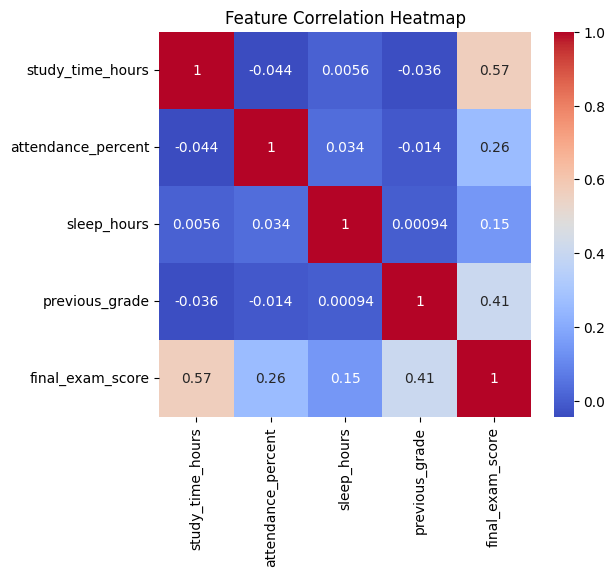

In [58]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

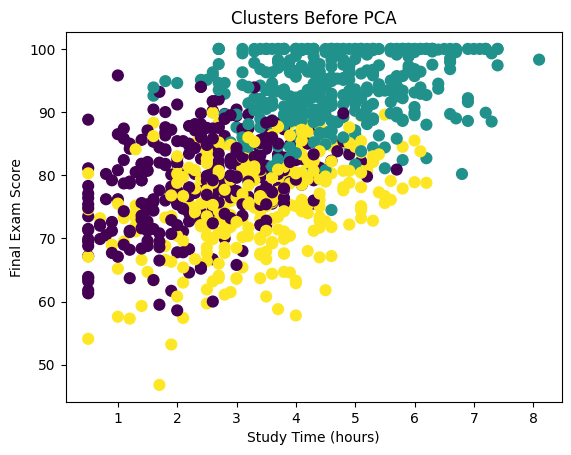

In [59]:
plt.scatter(df['study_time_hours'], df['final_exam_score'], c=df['Cluster_Before'], cmap='viridis', s=60)
plt.xlabel('Study Time (hours)')
plt.ylabel('Final Exam Score')
plt.title('Clusters Before PCA')
plt.show()

In [60]:
sil_before = silhouette_score(X_scaled, df['Cluster_Before'])
print('Silhouette Score (Before PCA):', round(sil_before, 3))

Silhouette Score (Before PCA): 0.175


## Apply PCA (2 Components)

In [61]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance retained:', round(pca.explained_variance_ratio_.sum(), 3))

Explained variance ratio: [0.34722013 0.21102003]
Total variance retained: 0.558


## K-Means AFTER PCA

In [62]:
kmeans_after = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_After'] = kmeans_after.fit_predict(X_pca)
df[features + ['Cluster_After']].head()


,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,Cluster_After
0,4.0,98.0,6.5,76.9,100.0,1
1,6.3,100.0,5.7,75.5,100.0,1
2,4.9,85.3,7.9,88.5,97.3,1
3,2.6,77.5,8.0,85.1,83.8,0
4,2.2,89.6,4.6,61.8,68.3,0


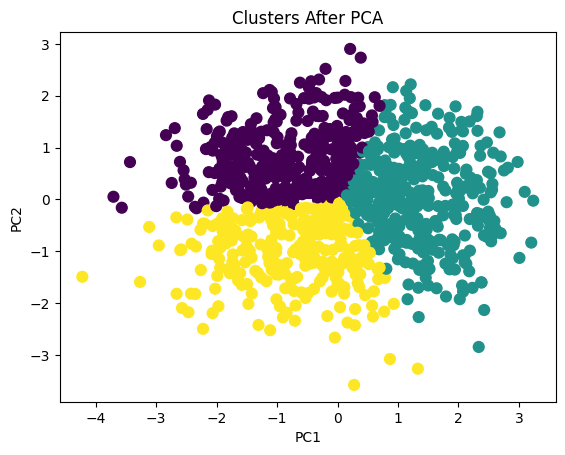

In [63]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_After'], cmap='viridis', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters After PCA')
plt.show()

In [64]:
sil_after = silhouette_score(X_pca, df['Cluster_After'])
print('Silhouette Score (After PCA):', round(sil_after, 3))

Silhouette Score (After PCA): 0.348


## Compare Silhouette Scores

In [65]:
print('Before PCA:', round(sil_before, 3))
print('After PCA: ', round(sil_after, 3))

Before PCA: 0.175
After PCA:  0.348


# Cluster Profiling
Using the clusters found **after PCA** (better separated), profile each group by its average original feature values.

In [66]:
cluster_profile = df.groupby('Cluster_After')[features].mean().round(2)
cluster_profile

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
Cluster_After,,,,,
0,2.20,88.67,6.99,68.01,77.29
1,4.58,88.02,7.07,76.48,93.47
2,3.88,77.08,6.23,63.02,77.98


# Cluster Interpretation

Use the profile table above to understand what each cluster represents.

### Cluster 0
- Study Time ≈ 2.2 hrs, Attendance ≈ 88.7%, Sleep ≈ 7.0 hrs
- Previous Grade ≈ 68, Final Exam Score ≈ 77.3

**Description:** Consistent Attenders with Moderate Study Effort

**Insight:** Good attendance habits, but exam scores could improve with more study time — a candidate group for study-skills support.

### Cluster 1
- Study Time ≈ 4.6 hrs, Attendance ≈ 88.0%, Sleep ≈ 7.1 hrs
- Previous Grade ≈ 76.5, Final Exam Score ≈ 93.5

**Description:** High Achievers

**Insight:** Strong study habits, attendance, and sleep combine for the best outcomes — a model group to encourage others toward.

### Cluster 2
- Study Time ≈ 3.9 hrs, Attendance ≈ 77.1%, Sleep ≈ 6.2 hrs
- Previous Grade ≈ 63.0, Final Exam Score ≈ 78.0

**Description:** At-Risk / Inconsistent Students

**Insight:** Lower attendance and sleep than other groups despite moderate study time — attendance and rest may be the bigger levers here, worth targeted intervention.

In [67]:
cluster_names = {
    0: 'Consistent Attenders',
    1: 'High Achievers',
    2: 'At-Risk / Inconsistent'
}

df['Cluster_Name'] = df['Cluster_After'].map(cluster_names)
df[features + ['Cluster_After', 'Cluster_Name']].head()

,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score,Cluster_After,Cluster_Name
0,4.0,98.0,6.5,76.9,100.0,1,High Achievers
1,6.3,100.0,5.7,75.5,100.0,1,High Achievers
2,4.9,85.3,7.9,88.5,97.3,1,High Achievers
3,2.6,77.5,8.0,85.1,83.8,0,Consistent Attenders
4,2.2,89.6,4.6,61.8,68.3,0,Consistent Attenders


##How did PCA affect clustering results?

 Improved separation: silhouette score rose from before to after PCA.


##Did visualization become clearer?

 Yes, 2D plot possible vs impossible with 5 raw features.


##Did you lose important information?

 Yes, only part of the original variance retained (~55%).


##Which approach is better and why?

 After PCA, clearer clusters and visualization, despite some information loss.

#bonus

In [68]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(n_clusters=3)
df['Cluster_Hierarchical'] = hierarchical.fit_predict(X_pca)

sil_hier = silhouette_score(X_pca, df['Cluster_Hierarchical'])
print('Silhouette Score (Hierarchical):', round(sil_hier, 3))

Silhouette Score (Hierarchical): 0.258


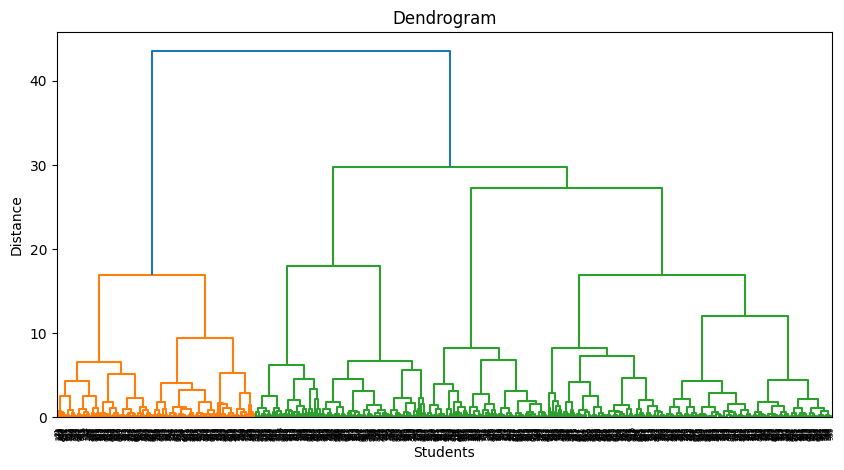

In [69]:


linked = linkage(X_pca, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Students')
plt.ylabel('Distance')
plt.show()

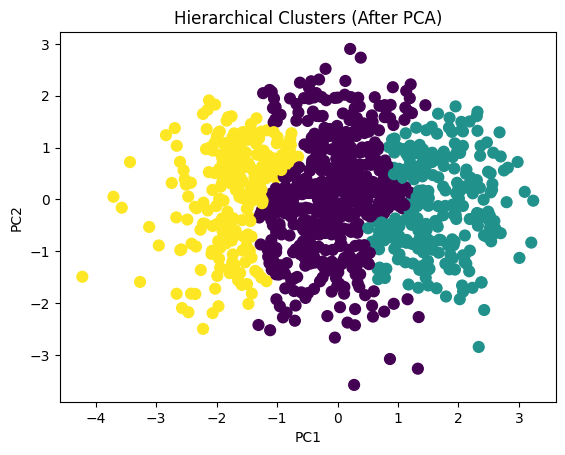

In [70]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster_Hierarchical'], cmap='viridis', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clusters (After PCA)')
plt.show()

In [71]:
print('KMeans Silhouette (After PCA):     ', round(sil_after, 3))
print('Hierarchical Silhouette (After PCA):', round(sil_hier, 3))

KMeans Silhouette (After PCA):      0.348
Hierarchical Silhouette (After PCA): 0.258


Data > Scaling > PCA > Clustering > Profiling > Interpretation > Insight

- PCA improved cluster separation (Silhouette Score rose from 0.175 before PCA to 0.348 after PCA), though it kept only ~55.8% of the original variance.

- K-Means groups students into 3 meaningful profiles: **Consistent Attenders**, **High Achievers**, and **At-Risk / Inconsistent** students.

- K-Means finds the clusters — the profiling and interpretation above is what turns those clusters into meaningful, actionable insight.

- **Bonus:** Hierarchical Clustering was also tested on the PCA-reduced data, giving a Silhouette Score of 0.258 — lower than KMeans (0.348), suggesting KMeans found better-separated groups for this dataset.